# 1 — Imports, config, device, seeds

In [1]:
import sys, time, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision import models

# -------- Config --------
IMG_SIZE    = 384
BATCH_SIZE  = 4
NUM_WORKERS = 0
EPOCHS      = 80
LR          = 1e-4
WEIGHT_DECAY = 1e-5

# -------- Root detection --------
root = Path.cwd()
while not (root / "Pipeline_").exists() and root != root.parent:
    root = root.parent

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print("Project root:", root)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


Project root: c:\repo\Waste-Classification
Device: cuda


# 2 — Paths, labelmap, class mapping

In [2]:
WARP_S_ROOT   = root / "Dataset/raw/Warp-S"
IMAGESETS_TXT = WARP_S_ROOT / "ImageSets/Segmentation/default.txt"
IMAGES_DIR    = WARP_S_ROOT / "JPEGImages"
MASKS_DIR     = WARP_S_ROOT / "SegmentationClass"
LABELMAP_FILE = WARP_S_ROOT / "labelmap.txt"

print("WaRP‑S root :", WARP_S_ROOT)
print("Images dir  :", IMAGES_DIR)
print("Masks dir   :", MASKS_DIR)
print("ImageSet    :", IMAGESETS_TXT)
print("Labelmap    :", LABELMAP_FILE)

class_names = []
rgb_to_id = {}

with open(LABELMAP_FILE, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        name, rest = line.split(":")[0], line.split(":")[1]
        rgb_str = rest.split("::")[0]
        r, g, b = map(int, rgb_str.split(","))
        class_names.append(name)
        rgb_to_id[(r, g, b)] = len(class_names) - 1

NUM_CLASSES = len(class_names)
print(f"Found {NUM_CLASSES} classes:")
for i, n in enumerate(class_names):
    print(f"{i:2d}: {n}")


WaRP‑S root : c:\repo\Waste-Classification\Dataset\raw\Warp-S
Images dir  : c:\repo\Waste-Classification\Dataset\raw\Warp-S\JPEGImages
Masks dir   : c:\repo\Waste-Classification\Dataset\raw\Warp-S\SegmentationClass
ImageSet    : c:\repo\Waste-Classification\Dataset\raw\Warp-S\ImageSets\Segmentation\default.txt
Labelmap    : c:\repo\Waste-Classification\Dataset\raw\Warp-S\labelmap.txt
Found 29 classes:
 0: background
 1: bottle-blue
 2: bottle-blue-full
 3: bottle-blue5l
 4: bottle-blue5l-full
 5: bottle-dark
 6: bottle-dark-full
 7: bottle-green
 8: bottle-green-full
 9: bottle-milk
10: bottle-milk-full
11: bottle-multicolor
12: bottle-multicolorv-full
13: bottle-oil
14: bottle-oil-full
15: bottle-transp
16: bottle-transp-full
17: bottle-yogurt
18: canister
19: cans
20: detergent-box
21: detergent-color
22: detergent-transparent
23: detergent-white
24: glass-dark
25: glass-green
26: glass-transp
27: juice-cardboard
28: milk-cardboard


# 3 — Load IDs

In [3]:
with open(IMAGESETS_TXT, "r") as f:
    all_ids = [line.strip() for line in f if line.strip()]

valid_ids = []
for img_id in all_ids:
    if (MASKS_DIR / f"{img_id}.png").exists():
        valid_ids.append(img_id)

print("Total valid IDs:", len(valid_ids))


Total valid IDs: 112


# 4 — Augmentations

In [4]:
class WarpSAugment:
    def __init__(self, size):
        self.size = size

    def __call__(self, img, mask_ids):
        if random.random() < 0.5:
            img = TF.hflip(img)
            mask_ids = np.fliplr(mask_ids)

        if random.random() < 0.5:
            angle = random.uniform(-8, 8)
            img = TF.rotate(img, angle, interpolation=TF.InterpolationMode.BILINEAR)
            mask_pil = Image.fromarray(mask_ids.astype(np.uint8), mode="L")
            mask_pil = TF.rotate(mask_pil, angle, interpolation=TF.InterpolationMode.NEAREST)
            mask_ids = np.array(mask_pil)

        if random.random() < 0.5:
            img = TF.adjust_brightness(img, 0.9 + 0.2 * random.random())
            img = TF.adjust_contrast(img, 0.9 + 0.2 * random.random())

        img = TF.resize(img, (self.size, self.size))
        mask_pil = Image.fromarray(mask_ids.astype(np.uint8), mode="L")
        mask_pil = TF.resize(mask_pil, (self.size, self.size),
                             interpolation=TF.InterpolationMode.NEAREST)
        mask_ids = np.array(mask_pil)

        img = TF.to_tensor(img)
        img = TF.normalize(
            img,
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )

        mask_ids = torch.as_tensor(mask_ids, dtype=torch.long)
        return img, mask_ids


# 5 — Palette‑aware mask loading + dataset

In [5]:
# ---------------------------------------------------------
# Nearest-RGB fallback (only used if mask is not palette)
# ---------------------------------------------------------
def rgb_to_class(mask_np, rgb_to_id):
    h, w, _ = mask_np.shape
    flat = mask_np.reshape(-1, 3)

    label_colors = np.array(list(rgb_to_id.keys()))
    label_ids    = np.array(list(rgb_to_id.values()))

    dists = np.linalg.norm(flat[:, None, :] - label_colors[None, :, :], axis=2)
    nearest = np.argmin(dists, axis=1)
    out = label_ids[nearest].reshape(h, w).astype(np.uint8)
    return out


# ---------------------------------------------------------
# Dataset
# ---------------------------------------------------------
class WarpSSegmentationDataset(Dataset):
    def __init__(self, ids, images_dir, masks_dir, augment, rgb_to_id):
        self.ids = ids
        self.images_dir = Path(images_dir)
        self.masks_dir  = Path(masks_dir)
        self.augment = augment
        self.rgb_to_id = rgb_to_id

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]

        img  = Image.open(self.images_dir / f"{img_id}.jpg").convert("RGB")
        mask = Image.open(self.masks_dir  / f"{img_id}.png")

        # Palette mask → class IDs directly
        if mask.mode == "P":
            mask_ids = np.array(mask, dtype=np.uint8)
        else:
            mask_np = np.array(mask.convert("RGB"))
            mask_ids = rgb_to_class(mask_np, self.rgb_to_id)

        if self.augment is not None:
            img, mask_ids = self.augment(img, mask_ids)
        else:
            img = TF.resize(img, (IMG_SIZE, IMG_SIZE))
            mask_pil = Image.fromarray(mask_ids.astype(np.uint8), mode="L")
            mask_pil = TF.resize(mask_pil, (IMG_SIZE, IMG_SIZE),
                                 interpolation=TF.InterpolationMode.NEAREST)
            mask_ids = np.array(mask_pil)

            img = TF.to_tensor(img)
            img = TF.normalize(
                img,
                mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]
            )
            mask_ids = torch.as_tensor(mask_ids, dtype=torch.long)

        return img, mask_ids


# 6 — Class‑aware stratified split

In [6]:
from collections import defaultdict

# Build mapping: image → classes
image_classes = defaultdict(set)

for img_id in valid_ids:
    mask = Image.open(MASKS_DIR / f"{img_id}.png")
    if mask.mode == "P":
        mask_ids = np.array(mask)
    else:
        mask_np = np.array(mask.convert("RGB"))
        mask_ids = rgb_to_class(mask_np, rgb_to_id)

    for u in np.unique(mask_ids):
        image_classes[img_id].add(int(u))

# Build class → images
class_to_images = defaultdict(list)
for img_id, classes in image_classes.items():
    for c in classes:
        class_to_images[c].append(img_id)

# Stratified split
train_ids = set()
val_ids   = set()

random.seed(42)

for c, imgs in class_to_images.items():
    if len(imgs) == 1:
        train_ids.add(imgs[0])
    else:
        val_choice = random.choice(imgs)
        val_ids.add(val_choice)
        for img in imgs:
            if img != val_choice:
                train_ids.add(img)

train_ids = sorted(list(train_ids))
val_ids   = sorted(list(val_ids))

print("Train:", len(train_ids))
print("Val:", len(val_ids))


Train: 112
Val: 28


# 7 — DataLoaders

In [7]:
train_ds = WarpSSegmentationDataset(
    ids=train_ids,
    images_dir=IMAGES_DIR,
    masks_dir=MASKS_DIR,
    augment=WarpSAugment(size=IMG_SIZE),
    rgb_to_id=rgb_to_id,
)

val_ds = WarpSSegmentationDataset(
    ids=val_ids,
    images_dir=IMAGES_DIR,
    masks_dir=MASKS_DIR,
    augment=None,
    rgb_to_id=rgb_to_id,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Train batches: 28
Val batches: 7


# 8 — ResNet50 backbone

In [8]:
class ResNet50Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.stem = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
        )
        self.layer1 = backbone.layer1  # 1/4
        self.layer2 = backbone.layer2  # 1/8
        self.layer3 = backbone.layer3  # 1/16
        self.layer4 = backbone.layer4  # 1/32

    def forward(self, x):
        x = self.stem(x)
        c1 = self.layer1(x)
        c2 = self.layer2(c1)
        c3 = self.layer3(c2)
        c4 = self.layer4(c3)
        return c1, c2, c3, c4


# 9 — ChannelLayerNorm + SegFormer‑Lite decoder

In [9]:
class ChannelLayerNorm(nn.Module):
    def __init__(self, num_channels):
        super().__init__()
        self.ln = nn.LayerNorm(num_channels)

    def forward(self, x):
        x = x.permute(0, 2, 3, 1)
        x = self.ln(x)
        x = x.permute(0, 3, 1, 2)
        return x


class MLPDecoderHead(nn.Module):
    def __init__(self, in_channels_list, embed_dim, num_classes):
        super().__init__()

        self.proj = nn.ModuleList()
        for in_ch in in_channels_list:
            self.proj.append(
                nn.Sequential(
                    nn.Conv2d(in_ch, embed_dim, kernel_size=1, bias=False),
                    ChannelLayerNorm(embed_dim),
                    nn.GELU(),
                )
            )

        self.fuse = nn.Sequential(
            nn.Conv2d(embed_dim * len(in_channels_list), embed_dim, kernel_size=1, bias=False),
            ChannelLayerNorm(embed_dim),
            nn.GELU(),
        )

        self.classifier = nn.Conv2d(embed_dim, num_classes, kernel_size=1)

    def forward(self, features):
        c1, c2, c3, c4 = features
        B, _, H, W = c1.shape

        outs = []
        for feat, proj in zip([c1, c2, c3, c4], self.proj):
            x = proj(feat)
            x = F.interpolate(x, size=(H, W), mode="bilinear", align_corners=False)
            outs.append(x)

        x = torch.cat(outs, dim=1)
        x = self.fuse(x)
        x = self.classifier(x)
        return x


# 10 — Full model

In [10]:
class ResNet50SegFormerLite(nn.Module):
    def __init__(self, num_classes, embed_dim=256):
        super().__init__()
        self.backbone = ResNet50Backbone()
        self.decoder = MLPDecoderHead(
            in_channels_list=[256, 512, 1024, 2048],
            embed_dim=embed_dim,
            num_classes=num_classes,
        )

    def forward(self, x):
        c1, c2, c3, c4 = self.backbone(x)
        logits_1_4 = self.decoder((c1, c2, c3, c4))
        logits = F.interpolate(
            logits_1_4,
            size=(x.shape[2], x.shape[3]),
            mode="bilinear",
            align_corners=False
        )
        return logits

model = ResNet50SegFormerLite(NUM_CLASSES).to(DEVICE)
print("Model ready.")


Model ready.


# 11 — Loss + metrics

In [11]:
criterion_ce = nn.CrossEntropyLoss()

def loss_fn(logits, masks):
    return criterion_ce(logits, masks)

def compute_metrics(logits, targets, num_classes):
    preds = logits.argmax(1)
    correct = (preds == targets).sum().item()
    total   = targets.numel()
    pix_acc = correct / total

    ious = []
    for c in range(num_classes):
        pred_c = (preds == c)
        targ_c = (targets == c)
        inter = (pred_c & targ_c).sum().item()
        union = (pred_c | targ_c).sum().item()
        if union > 0:
            ious.append(inter / union)
    miou = np.mean(ious) if ious else 0.0
    return pix_acc, miou


# 12 — Training loop

In [12]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_miou = 0.0
save_path = root / f"Models/weights/warp_s_resnet50_segformerlite_{IMG_SIZE}.pth"
save_path.parent.mkdir(parents=True, exist_ok=True)

for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    model.train()
    train_loss = 0.0

    if epoch <= 5:
        lr_scale = epoch / 5.0
        for pg in optimizer.param_groups:
            pg["lr"] = lr_scale * LR

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = loss_fn(logits, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    scheduler.step()

    model.eval()
    val_pix, val_miou = 0.0, 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            logits = model(imgs)
            pix, miou = compute_metrics(logits, masks, NUM_CLASSES)
            val_pix  += pix
            val_miou += miou

    val_pix  /= len(val_loader)
    val_miou /= len(val_loader)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"loss={train_loss/len(train_loader):.4f} | "
          f"val_pix={val_pix:.3f} | val_miou={val_miou:.3f} | "
          f"time={time.time()-t0:.1f}s")

    if val_miou > best_miou:
        best_miou = val_miou
        torch.save(model.state_dict(), save_path)
        print("  → Saved new best model.")


Epoch 01/80 | loss=2.7703 | val_pix=0.533 | val_miou=0.111 | time=9.0s
  → Saved new best model.
Epoch 02/80 | loss=2.3158 | val_pix=0.533 | val_miou=0.111 | time=9.0s
Epoch 03/80 | loss=2.2417 | val_pix=0.533 | val_miou=0.111 | time=9.0s
Epoch 04/80 | loss=2.1477 | val_pix=0.533 | val_miou=0.106 | time=9.0s
Epoch 05/80 | loss=1.9895 | val_pix=0.552 | val_miou=0.051 | time=9.1s
Epoch 06/80 | loss=1.8789 | val_pix=0.589 | val_miou=0.050 | time=9.1s
Epoch 07/80 | loss=1.7368 | val_pix=0.662 | val_miou=0.077 | time=9.2s
Epoch 08/80 | loss=1.6131 | val_pix=0.686 | val_miou=0.106 | time=9.1s
Epoch 09/80 | loss=1.4773 | val_pix=0.747 | val_miou=0.119 | time=9.0s
  → Saved new best model.
Epoch 10/80 | loss=1.3903 | val_pix=0.795 | val_miou=0.146 | time=9.1s
  → Saved new best model.
Epoch 11/80 | loss=1.2424 | val_pix=0.856 | val_miou=0.185 | time=9.1s
  → Saved new best model.
Epoch 12/80 | loss=1.1411 | val_pix=0.883 | val_miou=0.206 | time=9.0s
  → Saved new best model.
Epoch 13/80 | loss

# 13 — Per‑class IoU

In [13]:
model.load_state_dict(torch.load(save_path, map_location=DEVICE))
model.eval()

ious = {c: [] for c in range(NUM_CLASSES)}

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        logits = model(imgs)
        preds = logits.argmax(1)

        for c in range(NUM_CLASSES):
            pred_c = (preds == c)
            targ_c = (masks == c)
            inter = (pred_c & targ_c).sum().item()
            union = (pred_c | targ_c).sum().item()
            if union > 0:
                ious[c].append(inter / union)

class_iou = {c: (np.mean(v) if v else 0.0) for c, v in ious.items()}

print("Per‑Class IoU:")
for c, name in enumerate(class_names):
    print(f"{c:2d} {name:25s} IoU = {class_iou[c]:.3f}")

print("\nMean IoU:", np.mean(list(class_iou.values())))


Per‑Class IoU:
 0 background                IoU = 0.000
 1 bottle-blue               IoU = 0.936
 2 bottle-blue-full          IoU = 0.930
 3 bottle-blue5l             IoU = 0.959
 4 bottle-blue5l-full        IoU = 0.980
 5 bottle-dark               IoU = 0.959
 6 bottle-dark-full          IoU = 0.963
 7 bottle-green              IoU = 0.947
 8 bottle-green-full         IoU = 0.949
 9 bottle-milk               IoU = 0.963
10 bottle-milk-full          IoU = 0.984
11 bottle-multicolor         IoU = 0.952
12 bottle-multicolorv-full   IoU = 0.931
13 bottle-oil                IoU = 0.956
14 bottle-oil-full           IoU = 0.966
15 bottle-transp             IoU = 0.957
16 bottle-transp-full        IoU = 0.945
17 bottle-yogurt             IoU = 0.963
18 canister                  IoU = 0.957
19 cans                      IoU = 0.951
20 detergent-box             IoU = 0.938
21 detergent-color           IoU = 0.956
22 detergent-transparent     IoU = 0.967
23 detergent-white           IoU = 0.969
2

# 14 — Confusion matrix

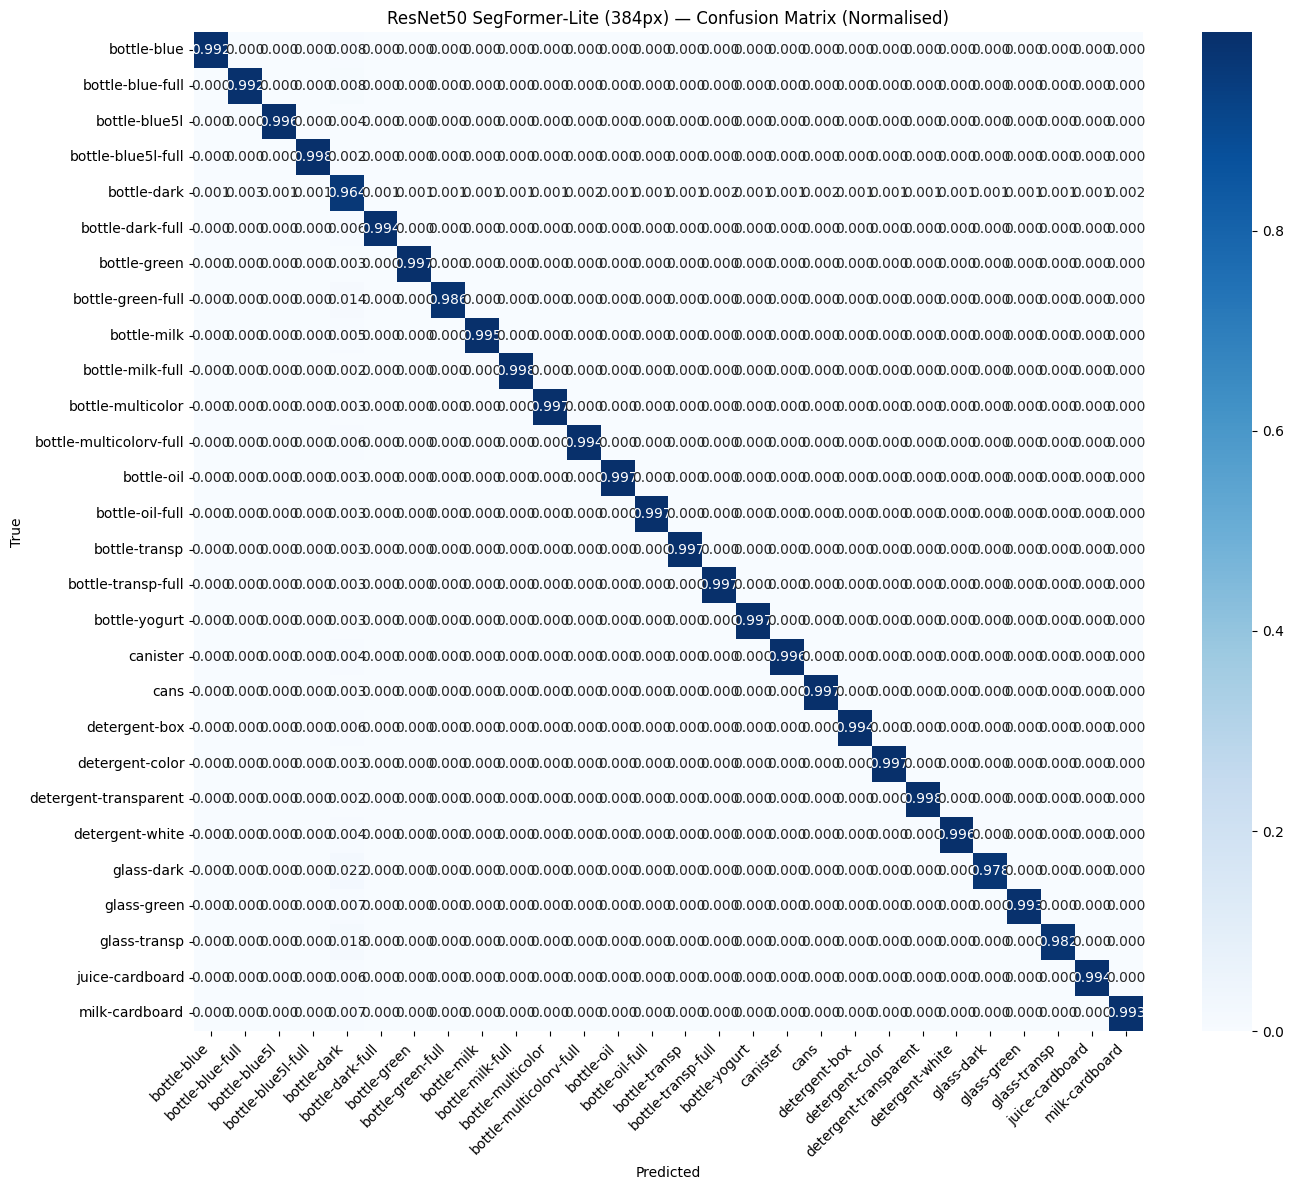

In [15]:
from sklearn.metrics import confusion_matrix

all_true = []
all_pred = []

model.eval()
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        logits = model(imgs)
        preds = logits.argmax(1)

        all_true.append(masks.cpu().numpy().reshape(-1))
        all_pred.append(preds.cpu().numpy().reshape(-1))

all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)

# Compute confusion matrix
cm = confusion_matrix(all_true, all_pred, labels=range(NUM_CLASSES))

# Filter out classes that do not appear in validation
valid_classes = [i for i in range(NUM_CLASSES) if cm[i].sum() > 0]
cm_valid = cm[np.ix_(valid_classes, valid_classes)]
names_valid = [class_names[i] for i in valid_classes]

# Normalise rows
row_sums = cm_valid.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_norm = cm_valid.astype(float) / row_sums

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=names_valid,
    yticklabels=names_valid
)
plt.title(f"ResNet50 SegFormer‑Lite ({IMG_SIZE}px) — Confusion Matrix (Normalised)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# 15 — Overlay Visualisation

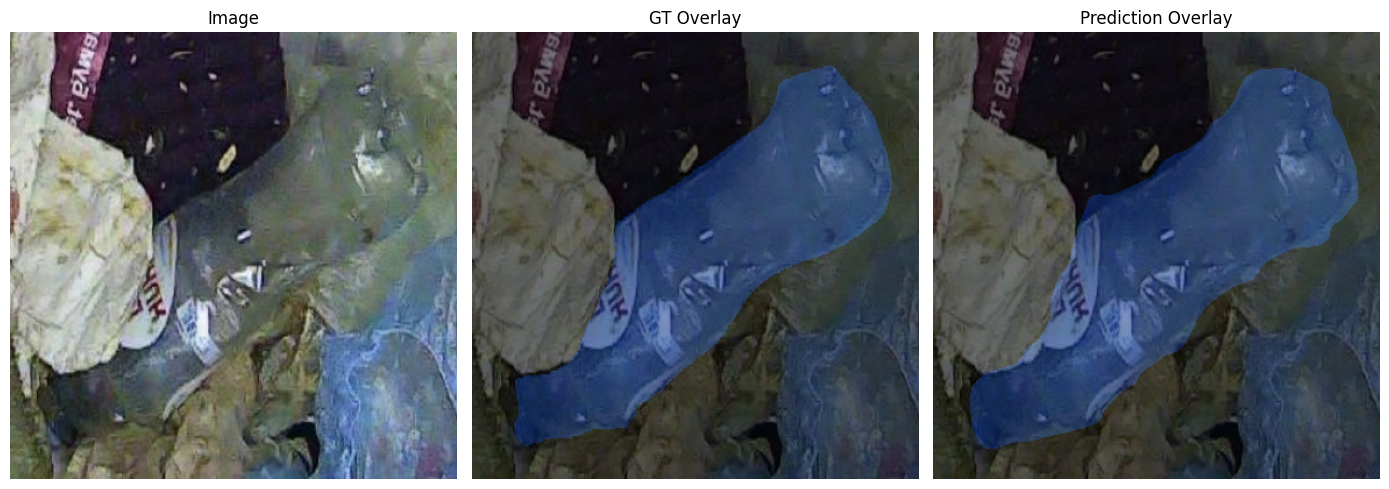

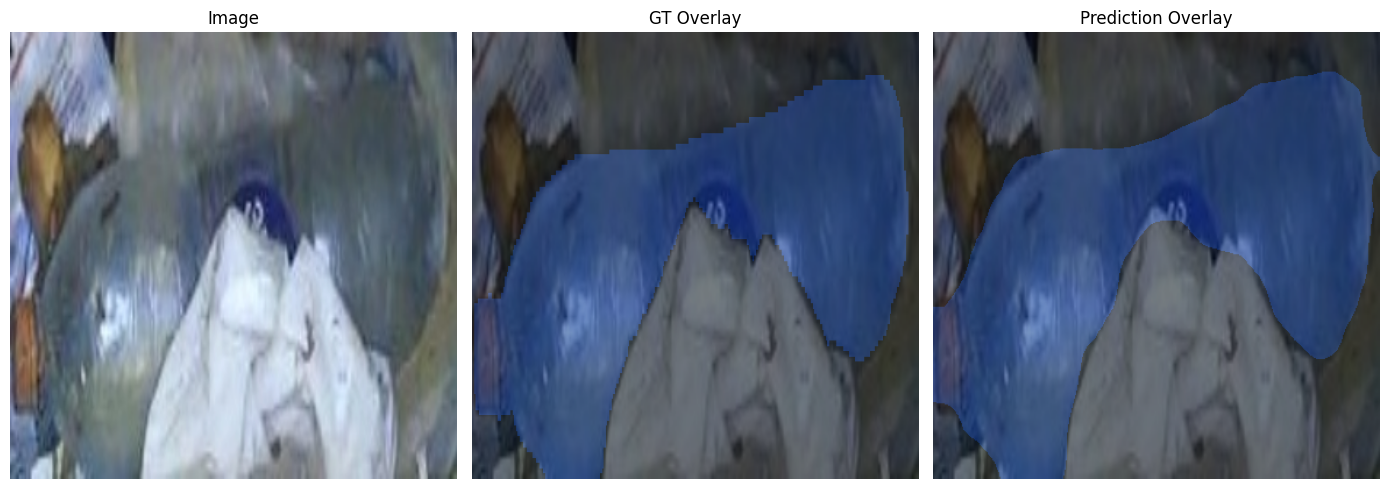

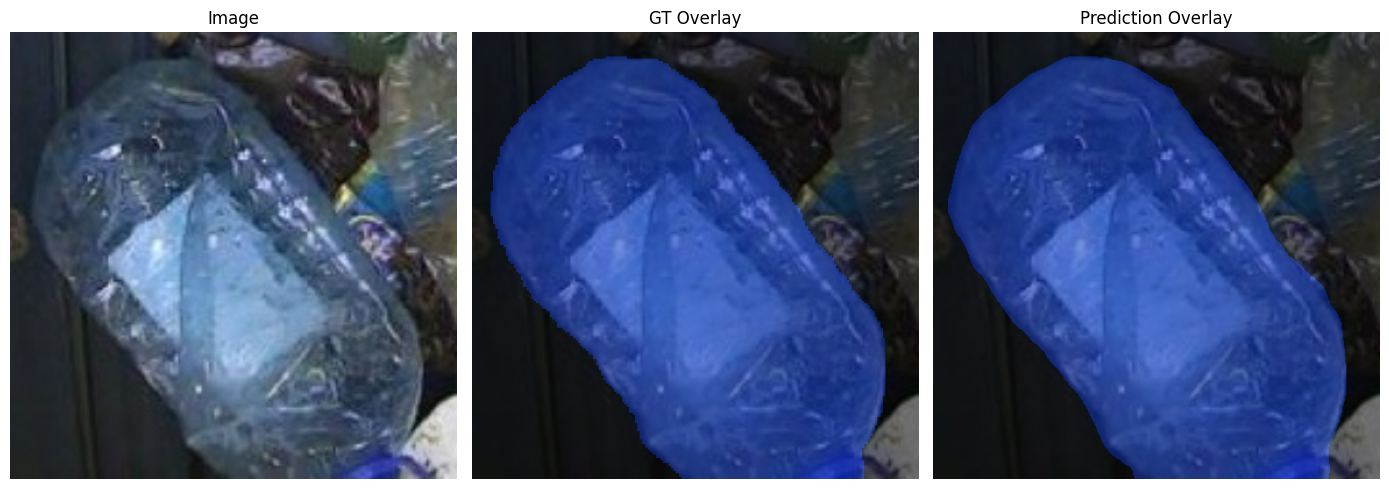

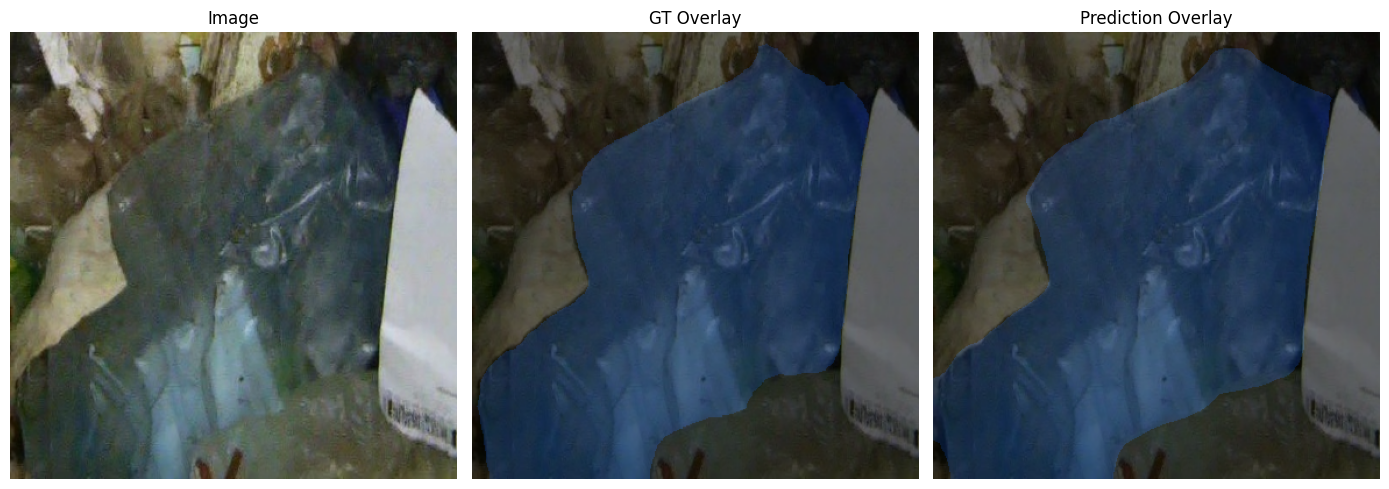

In [16]:
def decode_mask(mask_ids):
    h, w = mask_ids.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for (r, g, b), cid in rgb_to_id.items():
        rgb[mask_ids == cid] = (r, g, b)
    return rgb

def overlay_mask(image, mask_rgb, alpha=0.5):
    return (alpha * mask_rgb + (1 - alpha) * image).astype(np.uint8)

model.eval()
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        logits = model(imgs)
        preds = logits.argmax(1).cpu().numpy()
        masks_np = masks.cpu().numpy()
        imgs_np  = imgs.cpu().permute(0, 2, 3, 1).numpy()

        for j in range(min(4, imgs_np.shape[0])):
            # Un-normalise image
            img_vis = (imgs_np[j] * np.array([0.229, 0.224, 0.225]) +
                       np.array([0.485, 0.456, 0.406]))
            img_vis = (np.clip(img_vis, 0, 1) * 255).astype(np.uint8)

            gt_rgb   = decode_mask(masks_np[j])
            pred_rgb = decode_mask(preds[j])

            overlay_gt   = overlay_mask(img_vis, gt_rgb)
            overlay_pred = overlay_mask(img_vis, pred_rgb)

            fig, axs = plt.subplots(1, 3, figsize=(14, 5))
            axs[0].imshow(img_vis)
            axs[0].set_title("Image")
            axs[0].axis("off")

            axs[1].imshow(overlay_gt)
            axs[1].set_title("GT Overlay")
            axs[1].axis("off")

            axs[2].imshow(overlay_pred)
            axs[2].set_title("Prediction Overlay")
            axs[2].axis("off")

            plt.tight_layout()
            plt.show()

        break
